In [1]:
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from mplsoccer import VerticalPitch
import time
from tqdm import tqdm


sys.path.append("../")
from xThreat import xThreat

In [2]:
n_x = 16
n_y = 12

In [3]:
xT_true_16x12 = xThreat.load_from_pickle(f'../0-model-storage/xt-full-data-n_x{16}-n_y{12}.pickle')
xT_true_32x24 = xThreat.load_from_pickle(f'../0-model-storage/xt-full-data-n_x{32}-n_y{24}.pickle')
xT_true_64x48 = xThreat.load_from_pickle(f'../0-model-storage/xt-full-data-n_x{64}-n_y{48}.pickle')


In [4]:
df_euros = pd.read_parquet('../1-data-preparation/data-storage/xThreat_datav3_euros2020.parquet')

In [5]:
df_euros.describe()

,x,y,possession,possession_length,chain_length,match_id,period,player_id,shot_statsbomb_xg,under_pressure,next_x,next_y,next_under_pressure,next_team_id,next_player_id
count,92654.000000,92654.000000,92654.000000,92654.000000,92654.000000,9.265400e+04,92654.000000,92654.000000,619.000000,20416.0,92654.000000,92654.000000,20407.0,92654.000000,92654.000000
mean,51.333875,33.650458,89.303743,12.809172,8.329559,3.790811e+06,1.574417,10128.393291,0.140505,1.0,51.345598,33.648096,1.0,886.433538,10129.786906
std,23.291350,19.858639,55.170866,13.628198,10.101545,2.917399e+03,0.660055,8483.507971,0.196433,0.0,23.296198,19.857529,0.0,273.628451,8485.351214
min,0.350000,0.085000,2.000000,0.000000,0.000000,3.788741e+06,1.000000,2954.000000,0.004871,1.0,0.350000,0.085000,1.0,768.000000,2954.000000
25%,35.087500,16.171250,43.000000,3.000000,1.000000,3.788754e+06,1.000000,4870.000000,0.035180,1.0,35.175000,16.235000,1.0,772.000000,4870.000000
50%,50.925000,33.405000,85.000000,8.000000,5.000000,3.788767e+06,2.000000,6954.000000,0.060380,1.0,50.925000,33.405000,1.0,785.000000,6954.000000
75%,68.250000,51.085000,131.000000,18.000000,12.000000,3.794688e+06,2.000000,11514.000000,0.139786,1.0,68.250000,51.085000,1.0,912.000000,11514.000000
max,104.650000,67.915000,275.000000,119.000000,103.000000,3.795506e+06,5.000000,73852.000000,0.963011,1.0,104.650000,67.915000,1.0,2358.000000,73852.000000


In [6]:
player_ids = df_euros['player_id'].unique().tolist()

In [7]:
df_euros

,x,y,possession_kept,possession,possession_length,chain_length,previous_deleted,match_id,id,period,...,shot_outcome,shot_statsbomb_xg,pass_height,under_pressure,next_type,next_x,next_y,next_under_pressure,next_team_id,next_player_id
index,,,,,,,,,,,,,,,,,,,,,
2088,13.8250,6.375,True,3,0,0,True,3788741,4cbd1088-1580-43f5-8b09-58efabb753ff,1,...,None,NaN,None,NaN,Pass,2.8875,10.795,NaN,914.0,6954.0
9,2.8875,10.795,True,3,2,1,False,3788741,bfcfd5ad-1dda-44c9-9f3d-9b33b59983a6,1,...,None,NaN,Ground Pass,NaN,Carry,6.9125,30.770,NaN,914.0,7036.0
2089,6.9125,30.770,True,3,3,2,False,3788741,58ef2997-552a-4d3e-854a-cf863f9f5b71,1,...,None,NaN,None,NaN,Pass,7.9625,33.065,NaN,914.0,7036.0
10,7.9625,33.065,True,3,4,3,False,3788741,14604dfa-65b1-40c0-a11e-7c6b037806c0,1,...,None,NaN,Ground Pass,NaN,Carry,17.2375,40.715,NaN,914.0,7173.0
2090,17.2375,40.715,True,3,5,4,False,3788741,5eae5d7a-59cb-42e0-bfc0-c5a2e80493ee,1,...,None,NaN,None,NaN,Pass,25.2000,42.415,NaN,914.0,7173.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4383,94.4125,34.000,False,215,0,0,False,3795506,4811f0d8-75a6-49c9-b8c1-31a74b3d065b,5,...,Saved,0.7835,None,NaN,Shot,94.5875,34.000,NaN,768.0,3336.0
4384,94.5875,34.000,False,216,0,0,False,3795506,7ca98b9e-d86b-4557-a73a-6b612d0f56ec,5,...,Goal,0.7835,None,NaN,Shot,94.3250,34.000,NaN,914.0,7173.0
4385,94.3250,34.000,False,217,0,0,False,3795506,f21ac35f-5ca3-4965-bf47-17786bef12ab,5,...,Goal,0.7835,None,NaN,Shot,94.5000,33.915,NaN,768.0,3318.0


In [8]:
from statsbombpy import sb
import pandas as pd

# Get all competitions and find UEFA Euro 2020
competitions = sb.competitions()
euro_2020 = competitions[
    (competitions['competition_name'] == 'UEFA Euro') & (competitions['season_name'] == '2020')
]
competition_id = euro_2020.iloc[0]['competition_id']
season_id = euro_2020.iloc[0]['season_id']

# Get all matches
matches = sb.matches(competition_id=competition_id, season_id=season_id)
match_ids = matches['match_id'].tolist()

# Dictionary to store player minutes
player_minutes = {}

# Loop through each match
for match_id in match_ids:
    events = sb.events(match_id)

    # Get match duration (accounting for extra time)
    max_minute = events['minute'].max()

    # Track player substitutions
    player_in_times = {}  # {player_id: entry_minute}
    player_out_times = {} # {player_id: exit_minute}

    for _, event in events.iterrows():
        if event['type'] == 'Substitution':
            player_off = event['player']
            player_on = event['substitution_replacement']
            minute = event['minute']

            if player_off:
                player_out_times[player_off] = minute
            if player_on:
                player_in_times[player_on] = minute

    # Calculate minutes for all players
    for player in events['player'].dropna().unique():
        start_minute = player_in_times.get(player, 0)  # Defaults to starting lineup (0 min)
        end_minute = player_out_times.get(player, max_minute)  # Defaults to full game

        minutes_played = end_minute - start_minute
        player_minutes[player] = player_minutes.get(player, 0) + minutes_played

# Convert to DataFrame
players_df = pd.DataFrame(player_minutes.items(), columns=['Player', 'Minutes'])

# Filter for players with at least 300 minutes
filtered_players = players_df[players_df['Minutes'] >= 300]

# Display result
print(filtered_players)


                         Player  Minutes
0    Álvaro Borja Morata Martín      455
1          Pau Francisco Torres      395
2               Aymeric Laporte      658
3              Jordi Alba Ramos      581
5    Jorge Resurrección Merodio      483
..                          ...      ...
358           Toby Alderweireld      378
359              Thorgan Hazard      375
362            Thibaut Courtois      471
363              Thomas Meunier      342
437             Benjamin Pavard      320

[146 rows x 2 columns]


In [9]:
position_mapping = {
    'Goalkeeper': 'Goalkeeper',
    'Right Back': 'Defender', 'Left Back': 'Defender', 'Center Back': 'Defender', 'Right Center Back': 'Defender', 'Left Center Back': 'Defender',
    'Right Wing Back': 'Defender', 'Left Wing Back': 'Defender', 
    'Center Defensive Midfield': 'Midfielder', 'Left Defensive Midfield': 'Midfielder', 'Right Defensive Midfield': 'Midfielder',
    'Central Midfield': 'Midfielder', 
    'Center Attacking Midfield': 'Midfielder', 'Right Attacking Midfield': 'Midfielder', 'Left Attacking Midfield': 'Midfielder',
    'Left Center Forward': 'Attacker', 'Right Center Forward': 'Attacker',
    'Right Midfield': 'Midfielder', 'Left Midfield': 'Midfielder', 'Right Center Midfield': 'Midfielder', 'Left Center Midfield': 'Midfielder',
    'Right Wing': 'Attacker', 'Left Wing': 'Attacker', 'Center Forward': 'Attacker', 'Second Striker': 'Attacker'
}

In [10]:
from statsbombpy import sb
import pandas as pd

# Get all competitions and find UEFA Euro 2020
competitions = sb.competitions()
euro_2020 = competitions[
    (competitions['competition_name'] == 'UEFA Euro') & (competitions['season_name'] == '2020')
]
competition_id = euro_2020.iloc[0]['competition_id']
season_id = euro_2020.iloc[0]['season_id']

# Get all matches
matches = sb.matches(competition_id=competition_id, season_id=season_id)
match_ids = matches['match_id'].tolist()

# Dictionary to store player minutes
player_minutes = {}

# Dictionary to store player positions
player_positions = {}

# Dictionary to store player names for each id
player_ids = {}

# Loop through each match
for match_id in match_ids:
    events = sb.events(match_id)
    
    # Get match duration (accounting for extra time)
    max_minute = events['minute'].max()

    # Track player substitutions
    player_in_times = {}  # {player_name: entry_minute}
    player_out_times = {} # {player_name: exit_minute}

    for _, event in events.iterrows():
        if event['type'] == 'Substitution':
            player_off = event['player']
            player_on = event['substitution_replacement']
            minute = event['minute']

            if player_off:
                player_out_times[player_off] = minute
            if player_on:
                player_in_times[player_on] = minute

    # Calculate minutes for all players
    for player in events['player'].dropna().unique():
        start_minute = player_in_times.get(player, 0)  # Defaults to starting lineup (0 min)
        end_minute = player_out_times.get(player, max_minute)  # Defaults to full game

        minutes_played = end_minute - start_minute
        player_minutes[player] = player_minutes.get(player, 0) + minutes_played

    # Get lineup data for this match
    lineup_data = sb.lineups(match_id)

    # Extract player positions (lineup_data is a dictionary of DataFrames)
    for team_name, lineup_df in lineup_data.items():
        for _, player in lineup_df.iterrows():
            player_name = player['player_name']
            player_id = player['player_id']
            player_ids[player_name] = player_id

            game_player_positions = player_positions.get(player_name, {'Goalkeeper': 0, 'Defender': 0, 'Midfielder': 0, 'Attacker': 0})
            for position in player['positions']:
                game_player_positions[position_mapping[position['position']]] += 1
                
            player_positions[player_name] = game_player_positions

# Convert minutes to DataFrame
players_df = pd.DataFrame(player_minutes.items(), columns=['Player', 'Minutes'])

player_ids = pd.DataFrame(player_ids.items(), columns = ['Player', 'player_id'])

# Convert positions to DataFrame
player_names = player_positions.keys()
goalkeeper, defender, midfielder, attacker = [], [], [], []
for player_name in player_names:
    goalkeeper.append(player_positions[player_name]['Goalkeeper'])
    defender.append(player_positions[player_name]['Defender'])
    midfielder.append(player_positions[player_name]['Midfielder'])
    attacker.append(player_positions[player_name]['Attacker'])

positions_df = pd.DataFrame({
    'Player': player_names,
    'goalkeeper': goalkeeper,
    'defender': defender,
    'midfielder': midfielder,
    'attacker': attacker,
})
positions_df["main_position"] = positions_df[["goalkeeper", "defender", "midfielder", "attacker"]].idxmax(axis=1)


# Merge DataFrames
players_df = players_df.merge(positions_df, on='Player', how='left')
players_df = players_df.merge(player_ids, on='Player', how='left')

# Filter for players with at least 300 minutes
filtered_players = players_df[players_df['Minutes'] >= 300]

# Define broader position categories


# Display result
print(filtered_players)


                         Player  Minutes  goalkeeper  defender  midfielder  \
0    Álvaro Borja Morata Martín      455           0         0           0   
1          Pau Francisco Torres      395           0        10           0   
2               Aymeric Laporte      658           0        12           0   
3              Jordi Alba Ramos      581           0         6           0   
5    Jorge Resurrección Merodio      483           0         0           6   
..                          ...      ...         ...       ...         ...   
358           Toby Alderweireld      378           0         4           0   
359              Thorgan Hazard      375           0         5           0   
362            Thibaut Courtois      471           5         0           0   
363              Thomas Meunier      342           0         5           0   
437             Benjamin Pavard      320           0         4           0   

     attacker main_position  player_id  
0           8      att

In [11]:
players_df

,Player,Minutes,goalkeeper,defender,midfielder,attacker,main_position,player_id
0,Álvaro Borja Morata Martín,455,0,0,0,8,attacker,3477
1,Pau Francisco Torres,395,0,10,0,0,defender,6892
2,Aymeric Laporte,658,0,12,0,0,defender,4353
3,Jordi Alba Ramos,581,0,6,0,0,defender,5211
4,Pablo Sarabia García,267,0,0,1,10,attacker,6720
...,...,...,...,...,...,...,...,...
485,Andrey Semenov,91,0,2,0,0,defender,34588
486,Anton Shunin,91,1,0,0,0,goalkeeper,38119
487,Timothy Castagne,26,0,1,0,0,defender,6989
488,Yuri Zhirkov,42,0,1,0,0,defender,5193


In [12]:
filtered_players.head()

,Player,Minutes,goalkeeper,defender,midfielder,attacker,main_position,player_id
0,Álvaro Borja Morata Martín,455,0,0,0,8,attacker,3477
1,Pau Francisco Torres,395,0,10,0,0,defender,6892
2,Aymeric Laporte,658,0,12,0,0,defender,4353
3,Jordi Alba Ramos,581,0,6,0,0,defender,5211
5,Jorge Resurrección Merodio,483,0,0,6,0,midfielder,5199


# Filter on midfielders with at least 300 minutes

In [13]:
filtered_player_ids = filtered_players['player_id']
filtered_player_ids

0       3477
1       6892
2       4353
3       5211
5       5199
       ...  
358    20005
359     5632
362     3509
363     3176
437     5476
Name: player_id, Length: 146, dtype: int64

In [14]:
df_euros

,x,y,possession_kept,possession,possession_length,chain_length,previous_deleted,match_id,id,period,...,shot_outcome,shot_statsbomb_xg,pass_height,under_pressure,next_type,next_x,next_y,next_under_pressure,next_team_id,next_player_id
index,,,,,,,,,,,,,,,,,,,,,
2088,13.8250,6.375,True,3,0,0,True,3788741,4cbd1088-1580-43f5-8b09-58efabb753ff,1,...,None,NaN,None,NaN,Pass,2.8875,10.795,NaN,914.0,6954.0
9,2.8875,10.795,True,3,2,1,False,3788741,bfcfd5ad-1dda-44c9-9f3d-9b33b59983a6,1,...,None,NaN,Ground Pass,NaN,Carry,6.9125,30.770,NaN,914.0,7036.0
2089,6.9125,30.770,True,3,3,2,False,3788741,58ef2997-552a-4d3e-854a-cf863f9f5b71,1,...,None,NaN,None,NaN,Pass,7.9625,33.065,NaN,914.0,7036.0
10,7.9625,33.065,True,3,4,3,False,3788741,14604dfa-65b1-40c0-a11e-7c6b037806c0,1,...,None,NaN,Ground Pass,NaN,Carry,17.2375,40.715,NaN,914.0,7173.0
2090,17.2375,40.715,True,3,5,4,False,3788741,5eae5d7a-59cb-42e0-bfc0-c5a2e80493ee,1,...,None,NaN,None,NaN,Pass,25.2000,42.415,NaN,914.0,7173.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4383,94.4125,34.000,False,215,0,0,False,3795506,4811f0d8-75a6-49c9-b8c1-31a74b3d065b,5,...,Saved,0.7835,None,NaN,Shot,94.5875,34.000,NaN,768.0,3336.0
4384,94.5875,34.000,False,216,0,0,False,3795506,7ca98b9e-d86b-4557-a73a-6b612d0f56ec,5,...,Goal,0.7835,None,NaN,Shot,94.3250,34.000,NaN,914.0,7173.0
4385,94.3250,34.000,False,217,0,0,False,3795506,f21ac35f-5ca3-4965-bf47-17786bef12ab,5,...,Goal,0.7835,None,NaN,Shot,94.5000,33.915,NaN,768.0,3318.0


In [15]:
mask = df_euros['player_id'].isin(filtered_player_ids)
df_euros_filtered = df_euros[mask].copy()
df_euros_filtered

,x,y,possession_kept,possession,possession_length,chain_length,previous_deleted,match_id,id,period,...,shot_outcome,shot_statsbomb_xg,pass_height,under_pressure,next_type,next_x,next_y,next_under_pressure,next_team_id,next_player_id
index,,,,,,,,,,,,,,,,,,,,,
2088,13.8250,6.375,True,3,0,0,True,3788741,4cbd1088-1580-43f5-8b09-58efabb753ff,1,...,None,NaN,None,NaN,Pass,2.8875,10.795,NaN,914.0,6954.0
9,2.8875,10.795,True,3,2,1,False,3788741,bfcfd5ad-1dda-44c9-9f3d-9b33b59983a6,1,...,None,NaN,Ground Pass,NaN,Carry,6.9125,30.770,NaN,914.0,7036.0
2089,6.9125,30.770,True,3,3,2,False,3788741,58ef2997-552a-4d3e-854a-cf863f9f5b71,1,...,None,NaN,None,NaN,Pass,7.9625,33.065,NaN,914.0,7036.0
10,7.9625,33.065,True,3,4,3,False,3788741,14604dfa-65b1-40c0-a11e-7c6b037806c0,1,...,None,NaN,Ground Pass,NaN,Carry,17.2375,40.715,NaN,914.0,7173.0
2090,17.2375,40.715,True,3,5,4,False,3788741,5eae5d7a-59cb-42e0-bfc0-c5a2e80493ee,1,...,None,NaN,None,NaN,Pass,25.2000,42.415,NaN,914.0,7173.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3783,88.3750,66.045,True,210,20,20,False,3795506,d554972c-7ce9-4698-84e9-fb2b01fbfd97,4,...,None,NaN,None,NaN,Pass,71.0500,44.710,1.0,768.0,10955.0
1358,71.0500,44.710,False,211,0,0,True,3795506,22f76976-9167-4bc4-9ccb-66560d849b4a,4,...,None,NaN,High Pass,1.0,Shot,94.5000,34.000,NaN,768.0,10955.0
4382,94.5000,34.000,False,214,0,0,True,3795506,526593d2-c545-4433-aa71-f923a7dd7811,5,...,Goal,0.7835,None,NaN,Shot,94.4125,34.000,NaN,914.0,7471.0


## True model 16x12

In [16]:
df_euros_filtered['shot'] = ~df_euros_filtered['shot_outcome'].isna()
df_euros_filtered['goal'] = df_euros_filtered['shot_outcome'] == 'Goal'
df_euros_filtered = xT_true_16x12.quantify_action_quality(df_euros_filtered)

In [17]:
df_positive = df_euros_filtered[df_euros_filtered['action_xT'] > 0]
df_positive = df_positive.merge(filtered_players[['player_id', 'Minutes', 'main_position']], on='player_id', how='left')
df_positive.head()


,x,y,possession_kept,possession,possession_length,chain_length,previous_deleted,match_id,id,period,...,next_under_pressure,next_team_id,next_player_id,shot,goal,current_xT,next_xT,action_xT,Minutes,main_position
0,7.9625,33.065,True,3,4,3,False,3788741,14604dfa-65b1-40c0-a11e-7c6b037806c0,1,...,NaN,914.0,7173.0,False,False,0.004169,0.004707,0.000538,745,goalkeeper
1,17.2375,40.715,True,3,5,4,False,3788741,5eae5d7a-59cb-42e0-bfc0-c5a2e80493ee,1,...,NaN,914.0,7173.0,False,False,0.004707,0.005471,0.000765,702,defender
2,25.2000,42.415,True,3,6,5,False,3788741,2b3361c2-de34-4eea-bcd8-1815de59a72d,1,...,NaN,914.0,6954.0,False,False,0.005471,0.006063,0.000592,702,defender
3,27.8250,19.805,True,3,7,6,False,3788741,5096ab8c-c645-4ef6-b26b-c7fbd71a045f,1,...,NaN,914.0,6954.0,False,False,0.006063,0.006772,0.000708,466,defender
4,30.3625,34.255,True,3,10,9,False,3788741,73e19e02-1f83-4d0d-a468-bfa237c7943e,1,...,NaN,914.0,6954.0,False,False,0.006199,0.006474,0.000275,702,defender


In [18]:
df_positive_midfielders = df_positive[df_positive['main_position'] == 'midfielder']
df_positive_midfielders.head()

,x,y,possession_kept,possession,possession_length,chain_length,previous_deleted,match_id,id,period,...,next_under_pressure,next_team_id,next_player_id,shot,goal,current_xT,next_xT,action_xT,Minutes,main_position
14,25.3750,17.170,True,10,2,1,False,3788741,f7a8d09f-47d2-488d-9889-32e20a479fb2,1,...,NaN,914.0,8181.0,False,False,0.005422,0.006112,0.000690,730,midfielder
15,27.5625,26.350,True,10,4,3,False,3788741,58906030-6aa9-4389-aede-2757c30aa9e6,1,...,1.0,914.0,7131.0,False,False,0.006112,0.010063,0.003951,479,midfielder
20,41.8250,27.880,True,13,18,3,False,3788741,7e3a7331-6ced-493e-b4e5-3d22db32b601,1,...,1.0,914.0,7024.0,False,False,0.007689,0.009902,0.002213,730,midfielder
21,56.0000,21.845,True,13,19,4,False,3788741,4034d2db-f690-43c1-8fd9-66474298556f,1,...,1.0,914.0,7037.0,False,False,0.009902,0.010288,0.000386,730,midfielder
30,55.8250,65.450,True,15,4,4,False,3788741,745440b8-63a3-45eb-bf15-cdba21192eed,1,...,NaN,914.0,8181.0,False,False,0.008683,0.010063,0.001380,479,midfielder


In [19]:
xT_ratings = df_positive_midfielders.groupby('player_id').agg(
    xT_sum=('action_xT', 'sum'),
    action_count=('action_xT', 'count'),
    Minutes=('Minutes', 'first'),
    main_position=('main_position', 'first'),
).reset_index()
xT_ratings['xT_per_90'] = xT_ratings['xT_sum'] / xT_ratings['Minutes'] * 90
xT_ratings['Quartile'] = pd.qcut(xT_ratings['xT_per_90'], 4, labels=False) + 1
xT_ratings

,player_id,xT_sum,action_count,Minutes,main_position,xT_per_90,Quartile
0,2954.0,0.725121,124,349,midfielder,0.186994,3
1,3166.0,0.841334,346,399,midfielder,0.189775,3
2,3500.0,0.830335,233,409,midfielder,0.182714,3
3,3517.0,0.836163,76,363,midfielder,0.207313,4
4,3533.0,0.594734,89,367,midfielder,0.145847,2
5,3567.0,0.776364,72,379,midfielder,0.184361,3
6,3570.0,1.218184,287,594,midfielder,0.184573,3
7,3575.0,1.080725,153,496,midfielder,0.196099,3
8,3943.0,0.531382,247,541,midfielder,0.088400,1
9,3961.0,0.349330,190,415,midfielder,0.075758,1


In [20]:
# Simulation parameters
N_bootstrap = 1000
theta = 0.005

# Set random seed for reproducibility
np.random.seed(42)

# Prepare data for bootstrapping
xT_ratings.sort_values('player_id', inplace=True)
original_quartiles = xT_ratings['Quartile'].values
original_ratings = xT_ratings['xT_per_90'].values
number_of_actions = xT_ratings['action_count'].values
number_of_minutes = xT_ratings['Minutes'].values
n_players = len(original_ratings)

# Initialize arrays to store bootstrap results
bootstrap_quartile_changes = np.zeros(N_bootstrap)

for i_bootstrap in range(N_bootstrap):
    bootstrap_ratings = original_ratings.copy()

    for i_player in range(n_players):
        bootstrap_ratings[i_player] += np.random.uniform(-theta, theta, size=number_of_actions[i_player]).sum()/number_of_minutes[i_player] * 90
    bootstrap_quartiles = pd.qcut(bootstrap_ratings, 4, labels=False) + 1
    bootstrap_quartile_changes[i_bootstrap] = np.sum(bootstrap_quartiles != original_quartiles)

N_wrong = (bootstrap_quartile_changes > 4).sum()
print(f"With theta={theta}: {N_wrong/N_bootstrap*100:.2f}% ({N_wrong}) out ouf {N_bootstrap} bootstrap samples had more than 4 quantile changes due to the noise.")



With theta=0.005: 33.60% (336) out ouf 1000 bootstrap samples had more than 4 quantile changes due to the noise.


# Perform simulations

In [21]:
# Simulation parameters
N_bootstrap = 10_000
thetas = np.linspace(0.001, 0.005)

In [22]:
# Prepare data for bootstrapping
xT_ratings.sort_values('player_id', inplace=True)
original_quartiles = xT_ratings['Quartile'].values
original_ratings = xT_ratings['xT_per_90'].values
number_of_actions = xT_ratings['action_count'].values
number_of_minutes = xT_ratings['Minutes'].values
n_players = len(original_ratings)

## Test different distributions

In [23]:
# Initialize arrays to store bootstrap results
bootstrap_quartile_changes = np.zeros((N_bootstrap, len(thetas)))

for i_theta in tqdm(range(len(thetas))):
    theta = thetas[i_theta]
    for i_bootstrap in range(N_bootstrap):
        bootstrap_ratings = original_ratings.copy()

        for i_player in range(n_players):
            bootstrap_ratings[i_player] += np.random.uniform(-theta, theta, size=number_of_actions[i_player]).sum()/number_of_minutes[i_player] * 90
        bootstrap_quartiles = pd.qcut(bootstrap_ratings, 4, labels=False) + 1
        bootstrap_quartile_changes[i_bootstrap, i_theta] = np.sum(bootstrap_quartiles != original_quartiles)

# Calculate the percentage of bootstrap samples with more than 4 quantile changes
N_wrong = (bootstrap_quartile_changes > 4).sum(axis=0)
percent_wrong = N_wrong / N_bootstrap * 100


100%|██████████| 50/50 [05:57<00:00,  7.14s/it]


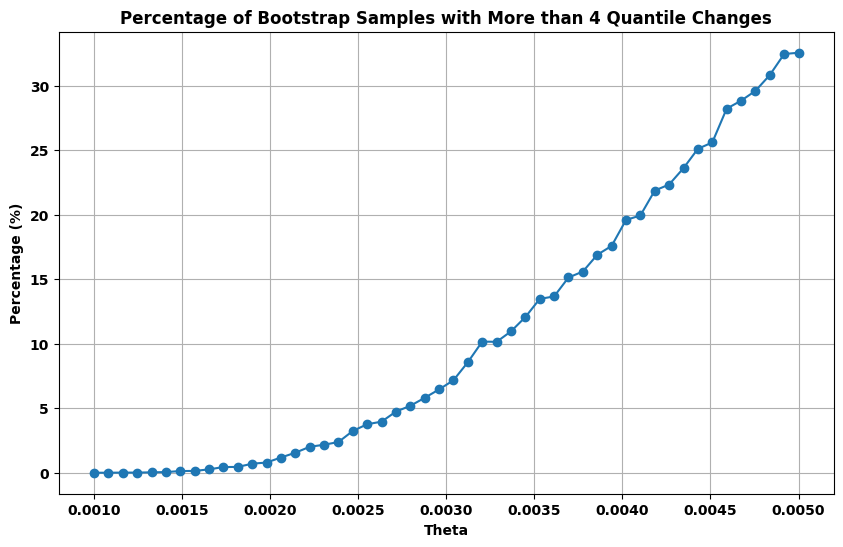

In [24]:
# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(thetas, percent_wrong, marker='o')
plt.title('Percentage of Bootstrap Samples with More than 4 Quantile Changes')
plt.xlabel('Theta')
plt.ylabel('Percentage (%)')


plt.grid()

plt.show()


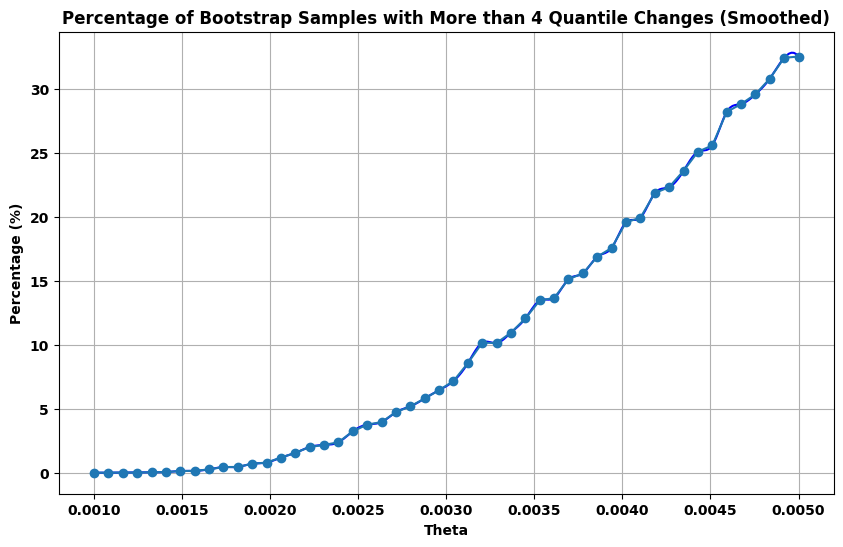

In [25]:
# Same plot but with smoothing
from scipy.interpolate import make_interp_spline
import matplotlib.pyplot as plt

# Create a smooth line using B-spline interpolation
xnew = np.linspace(thetas.min(), thetas.max(), 300)
spl = make_interp_spline(thetas, percent_wrong, k=3)  # k=3 for cubic spline
y_smooth = spl(xnew)
# Plot the smoothed line
plt.figure(figsize=(10, 6))
plt.plot(xnew, y_smooth, color='blue')
plt.plot(thetas, percent_wrong, marker='o')
plt.title('Percentage of Bootstrap Samples with More than 4 Quantile Changes (Smoothed)')
plt.xlabel('Theta')
plt.ylabel('Percentage (%)')
plt.grid()
plt.show()

Cut-off value was 1000, theta was 1.0.
Average fluctuation was 0.79795 and the max fluctuation was 4.47908.
Ratio Average/Max fluctuation was 0.17815.


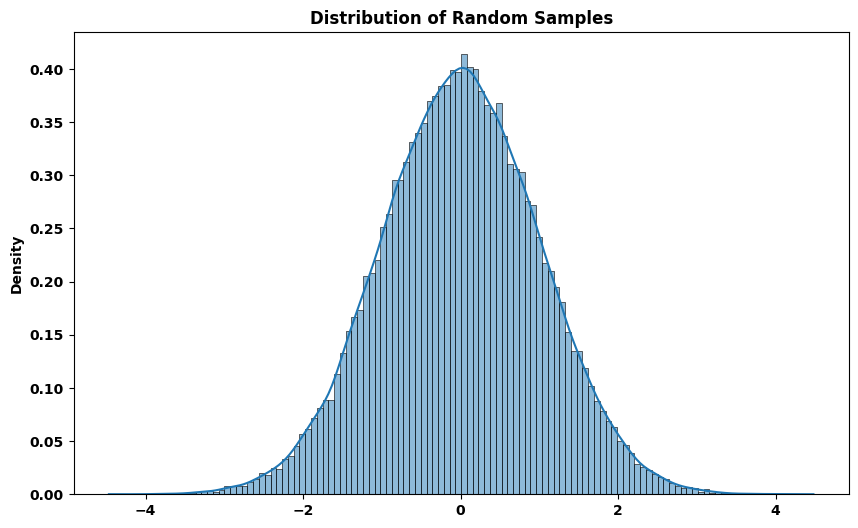

In [26]:
np.random.seed(42)

cut_off_value = 1000
theta = 1.0

samples = np.random.normal(size = 50_000, scale=theta)
samples[samples > cut_off_value] = cut_off_value
samples[samples < -cut_off_value] = -cut_off_value

print(f'Cut-off value was {cut_off_value}, theta was {theta}.')
print(f'Average fluctuation was {np.abs(samples).mean():.5f} and the max fluctuation was {np.abs(samples).max():.5f}.')
print(f'Ratio Average/Max fluctuation was {np.abs(samples).mean()/np.abs(samples).max():.5f}.')

plt.figure(figsize=(10, 6))
sns.histplot(samples, kde=True, stat='density')
plt.title('Distribution of Random Samples')

plt.show()

In [27]:
cut_off_value * theta

1000.0

Cut-off value was 1000, theta was 1.0.
Average fluctuation was 0.00035 and the max fluctuation was 0.01000.
Ratio Average/Max fluctuation was 0.03498.


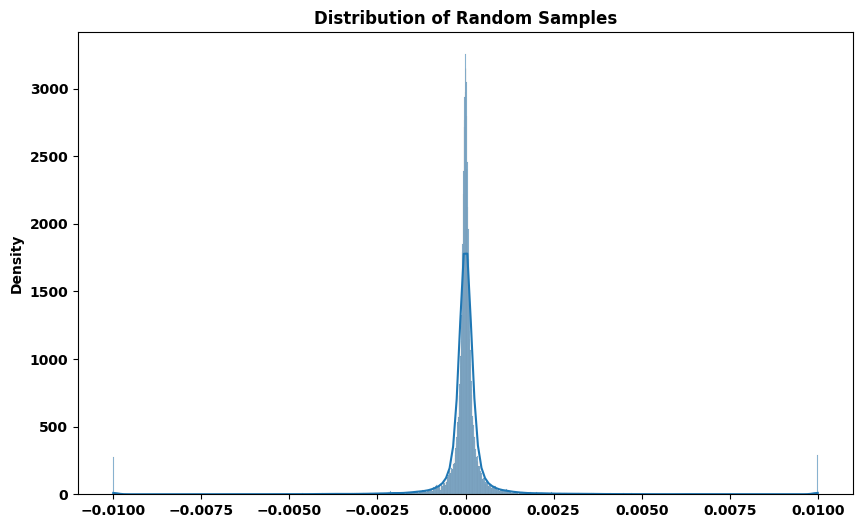

In [28]:
np.random.seed(42)


max_val = 0.010
scale = 5

samples = np.random.standard_t(size = 50_000, df=1) * max_val / 100
samples[samples > max_val] = max_val
samples[samples < -max_val] = -max_val

print(f'Cut-off value was {cut_off_value}, theta was {theta}.')
print(f'Average fluctuation was {np.abs(samples).mean():.5f} and the max fluctuation was {np.abs(samples).max():.5f}.')
print(f'Ratio Average/Max fluctuation was {np.abs(samples).mean()/np.abs(samples).max():.5f}.')

plt.figure(figsize=(10, 6))
sns.histplot(samples, kde=True, stat='density')
plt.title('Distribution of Random Samples')

plt.show()

Cut-off value was 100, theta was 1.
Average fluctuation was 0.06808 and the max fluctuation was 100.00000.
Ratio Average/Max fluctuation was 0.00068.


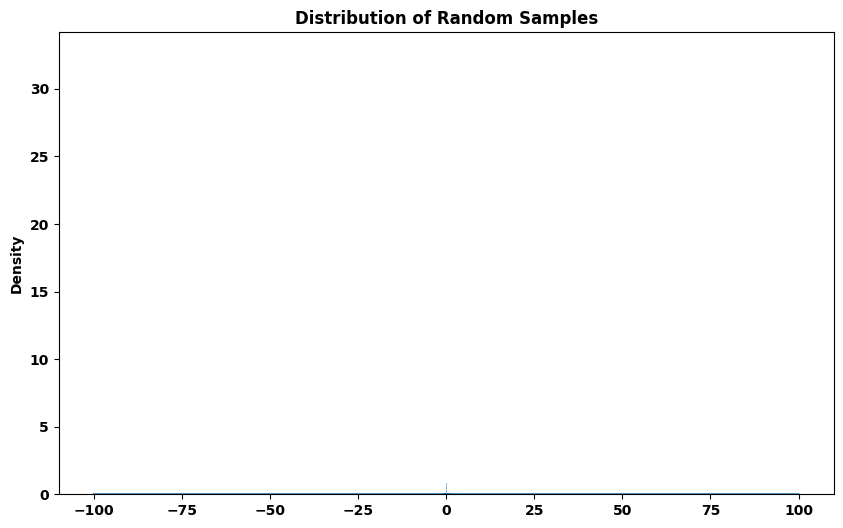

In [29]:
np.random.seed(42)


max_val = 100

cut_off_value = 100 #25 # For standard student t-distribution
theta = 1# 0.00012

samples = np.random.standard_t(size = 50_000, df=1) * theta / 100
samples[samples > cut_off_value * theta] = cut_off_value * theta
samples[samples < -cut_off_value * theta] = -cut_off_value * theta

print(f'Cut-off value was {cut_off_value}, theta was {theta}.')
print(f'Average fluctuation was {np.abs(samples).mean():.5f} and the max fluctuation was {np.abs(samples).max():.5f}.')
print(f'Ratio Average/Max fluctuation was {np.abs(samples).mean()/np.abs(samples).max():.5f}.')

plt.figure(figsize=(10, 6))
sns.histplot(samples, kde=True, stat='density')
plt.title('Distribution of Random Samples')

plt.show()

Average fluctuation was 0.78098 and the max fluctuation was 2.00000 (theta=1).


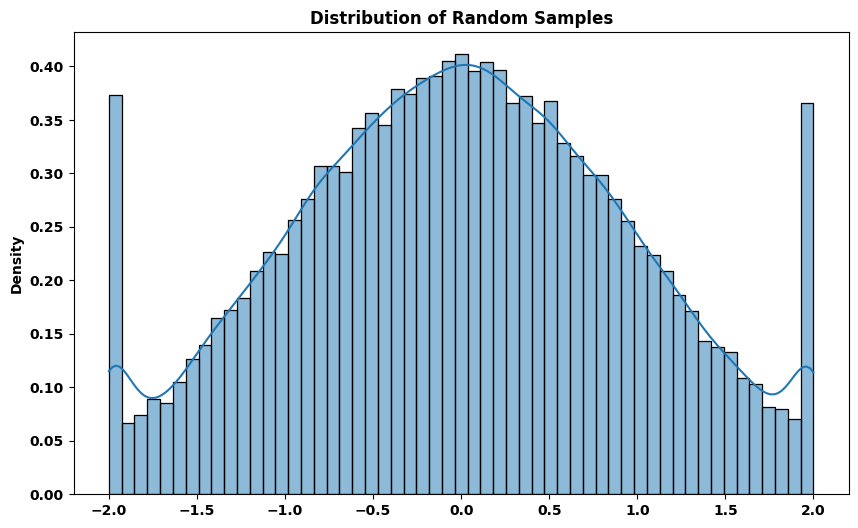

In [30]:
np.random.seed(42)

samples = np.random.normal(size = 50_000)
samples[samples > 2] = 2
samples[samples < -2] = -2

print(f'Average fluctuation was {np.abs(samples).mean():.5f} and the max fluctuation was {np.abs(samples).max():.5f} (theta={theta}).')

plt.figure(figsize=(10, 6))
sns.histplot(samples, kde=True, stat='density')
plt.title('Distribution of Random Samples')

plt.show()

In [31]:
# Initialize arrays to store bootstrap results
bootstrap_quartile_changes_norm = np.zeros((N_bootstrap, len(thetas)))

for i_theta in tqdm(range(len(thetas))):
    theta = thetas[i_theta]
    for i_bootstrap in range(N_bootstrap):
        bootstrap_ratings = original_ratings.copy()

        for i_player in range(n_players):
            samples = np.random.normal(size = number_of_actions[i_player], scale=theta/2)
            samples[samples > theta] = theta
            samples[samples < -theta] = -theta
            bootstrap_ratings[i_player] += samples.sum()/number_of_minutes[i_player] * 90
        bootstrap_quartiles = pd.qcut(bootstrap_ratings, 4, labels=False) + 1
        bootstrap_quartile_changes_norm[i_bootstrap, i_theta] = np.sum(bootstrap_quartiles != original_quartiles)

# Calculate the percentage of bootstrap samples with more than 4 quantile changes
N_wrong_norm = (bootstrap_quartile_changes_norm > 4).sum(axis=0)
percent_wrong_norm = N_wrong_norm / N_bootstrap * 100


100%|██████████| 50/50 [07:35<00:00,  9.10s/it]


In [32]:
0.003/25

0.00012

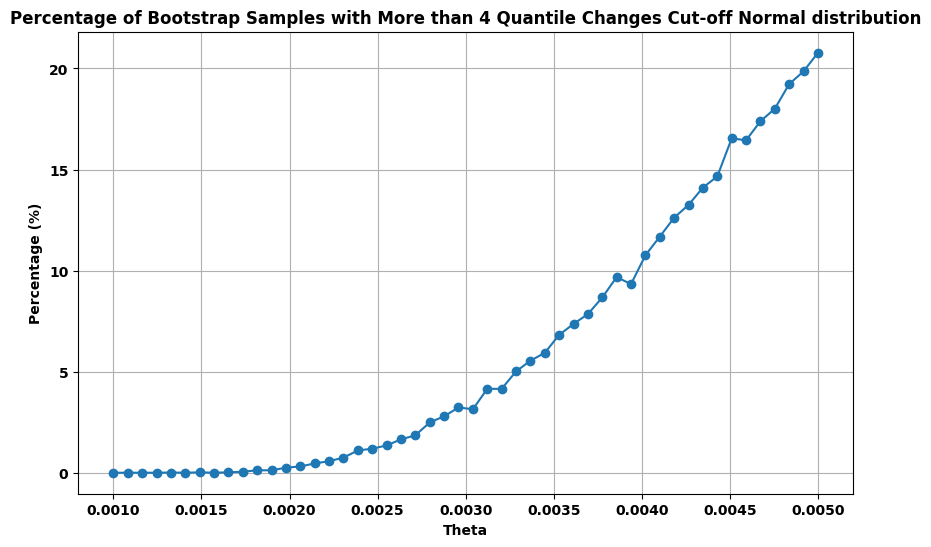

In [33]:
# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(thetas, percent_wrong_norm, marker='o')
plt.title('Percentage of Bootstrap Samples with More than 4 Quantile Changes Cut-off Normal distribution')
plt.xlabel('Theta')
plt.ylabel('Percentage (%)')


plt.grid()

plt.show()

In [34]:
thetas

array([0.001     , 0.00108163, 0.00116327, 0.0012449 , 0.00132653,
       0.00140816, 0.0014898 , 0.00157143, 0.00165306, 0.00173469,
       0.00181633, 0.00189796, 0.00197959, 0.00206122, 0.00214286,
       0.00222449, 0.00230612, 0.00238776, 0.00246939, 0.00255102,
       0.00263265, 0.00271429, 0.00279592, 0.00287755, 0.00295918,
       0.00304082, 0.00312245, 0.00320408, 0.00328571, 0.00336735,
       0.00344898, 0.00353061, 0.00361224, 0.00369388, 0.00377551,
       0.00385714, 0.00393878, 0.00402041, 0.00410204, 0.00418367,
       0.00426531, 0.00434694, 0.00442857, 0.0045102 , 0.00459184,
       0.00467347, 0.0047551 , 0.00483673, 0.00491837, 0.005     ])

## Find cut-off point Student t distribution

The student t distribution is most suitable because of the more heavy tails. We would like the relationship between the maximal errror and the average error to be the same. Therefore, we will now try to find the cut-off point to get this done. We can then rescale the distribution to have the correct maximal error.

In [35]:
# Mean error/max error
mean_max_ratio = 0.0158860

In [36]:
cut_off_points = np.linspace(0.001, 300, 2000)
mean_max_ratios = np.zeros(len(cut_off_points))

np.random.seed(42)

for i in tqdm(range(len(cut_off_points))):
    cut_off_value = cut_off_points[i]

    samples = np.random.standard_t(size = 1_000_000, df=1)
    samples[samples > cut_off_value] = cut_off_value
    samples[samples < -cut_off_value] = -cut_off_value
    
    mean_max_ratios[i] = np.abs(samples).mean()/np.abs(samples).max()

100%|██████████| 2000/2000 [02:57<00:00, 11.26it/s]


In [37]:
cut_off_factor = cut_off_points[np.argmin(np.abs(mean_max_ratios - mean_max_ratio))]
cut_off_factor

np.float64(263.5318874437218)

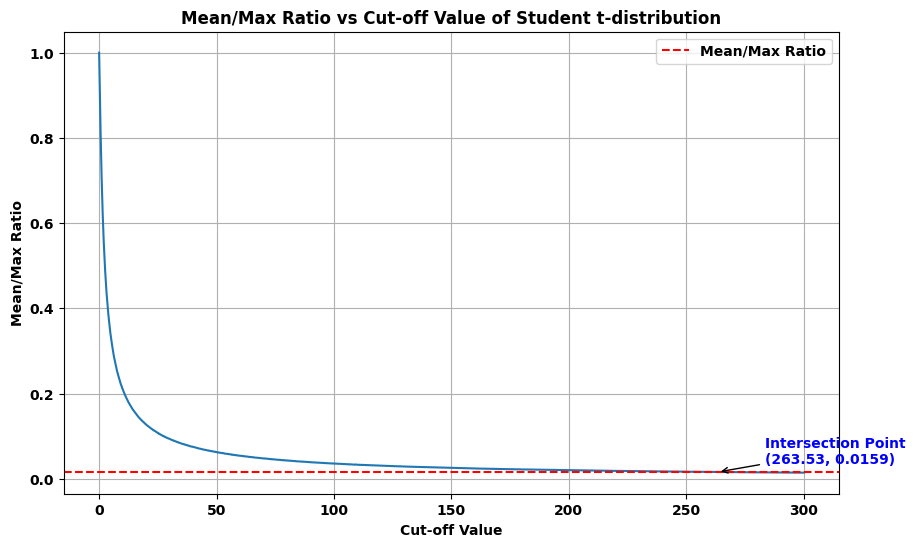

In [38]:
# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(cut_off_points, mean_max_ratios)
plt.axhline(y=mean_max_ratio, color='r', linestyle='--', label='Mean/Max Ratio')
# Annotate intersecting point
intersection_idx = np.argmin(np.abs(mean_max_ratios - mean_max_ratio))
intersection_x = cut_off_points[intersection_idx]
intersection_y = mean_max_ratios[intersection_idx]
plt.annotate(f'Intersection Point\n({intersection_x:.2f}, {intersection_y:.4f})',
             xy=(intersection_x, intersection_y), xytext=(intersection_x + 20, intersection_y + 0.02),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10, color='blue')
plt.legend()
plt.title('Mean/Max Ratio vs Cut-off Value of Student t-distribution')
plt.xlabel('Cut-off Value')
plt.ylabel('Mean/Max Ratio')
plt.grid()
plt.show()


We can see that the cut-off point should be 269. We will now plot the resulting distribution.

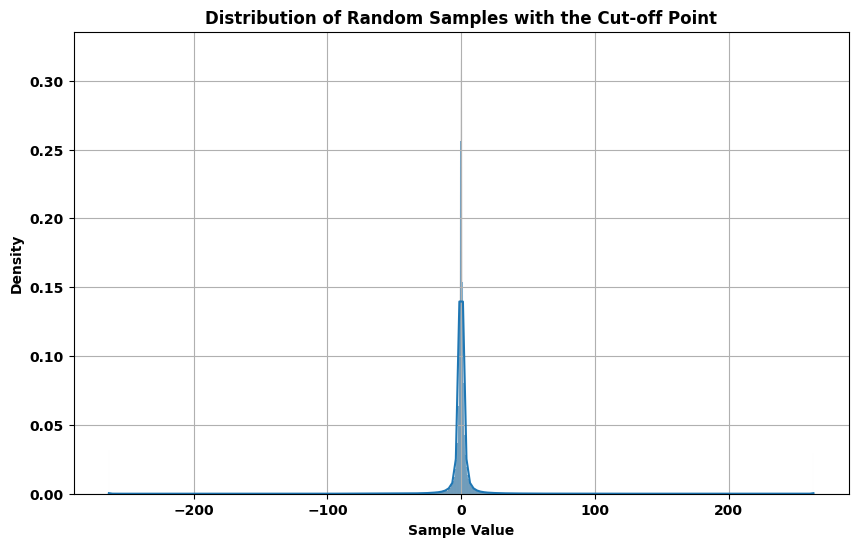

The mean/max ratio is 0.015938353036344416 with max error 263.5318874437218.


In [39]:
np.random.seed(42)

samples = np.random.standard_t(size = 1_000_000, df=1)
samples[samples > cut_off_factor] = cut_off_factor
samples[samples < -cut_off_factor] = -cut_off_factor

# Plot the distribution
plt.figure(figsize=(10, 6))
sns.histplot(samples, kde=True, stat='density')
plt.title('Distribution of Random Samples with the Cut-off Point')
plt.xlabel('Sample Value')
plt.ylabel('Density')
plt.grid()
plt.show()

print(f'The mean/max ratio is {np.abs(samples).mean()/np.abs(samples).max()} with max error {np.abs(samples).max()}.')

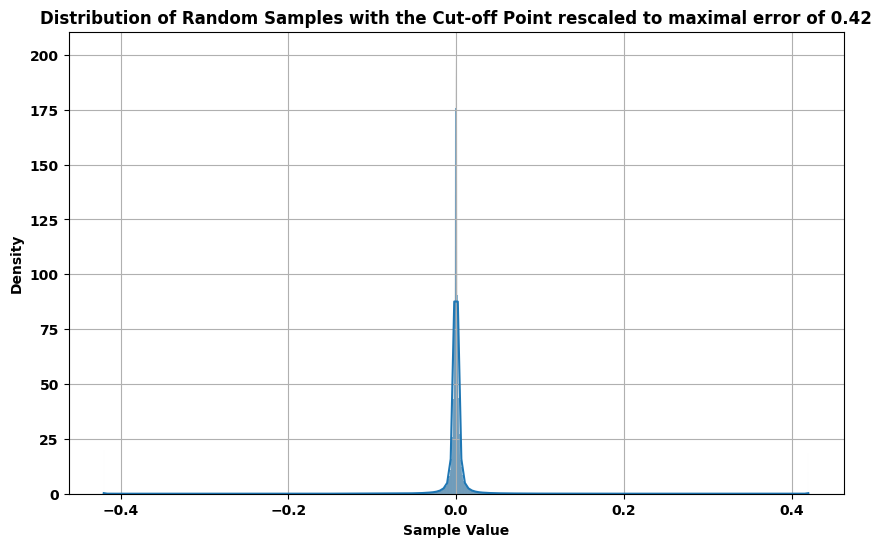

The mean/max ratio is 0.015938353036344433 with max error 0.42.


In [40]:
np.random.seed(42)

max_error = 0.42

samples = np.random.standard_t(size = 1_000_000, df=1) * max_error / cut_off_factor
samples[samples > max_error] = max_error
samples[samples < -max_error] = -max_error

# Plot the distribution
plt.figure(figsize=(10, 6))
sns.histplot(samples, kde=True, stat='density')
plt.title('Distribution of Random Samples with the Cut-off Point rescaled to maximal error of 0.42')
plt.xlabel('Sample Value')
plt.ylabel('Density')
plt.grid()
plt.show()

print(f'The mean/max ratio is {np.abs(samples).mean()/np.abs(samples).max()} with max error {np.abs(samples).max()}.')

# Perform the simulations

In [41]:
# Prepare data for bootstrapping
xT_ratings.sort_values('player_id', inplace=True)
original_quartiles = xT_ratings['Quartile'].values
original_ratings = xT_ratings['xT_per_90'].values
number_of_actions = xT_ratings['action_count'].values
number_of_minutes = xT_ratings['Minutes'].values
n_players = len(original_ratings)

In [42]:
# Define range of max errors and number of bootstraps
N_bootstrap = 10_000
max_errors = np.linspace(0.1, 0.01, 100)

# Set seed for repeatability
np.random.seed(42)

# Initialize arrays to store bootstrap results
bootstrap_quartile_changes_student = np.zeros((N_bootstrap, len(max_errors)))

for i_max_error in tqdm(range(len(max_errors))):
    max_error = max_errors[i_max_error]
    for i_bootstrap in range(N_bootstrap):

        # Get the ratings
        bootstrap_ratings = original_ratings.copy()

        for i_player in range(n_players):
            # Sample the errors
            samples = np.random.standard_t(size = number_of_actions[i_player], df=1) * max_error / cut_off_factor
            samples[samples > max_error] = max_error
            samples[samples < -max_error] = -max_error

            # Calculate the new rating
            # Rescale the samples to per 90 minutes
            bootstrap_ratings[i_player] += samples.sum()/number_of_minutes[i_player] * 90
        
        # Calculate the new quartiles
        # Note: pd.qcut returns 0-based indices, so we add 1 to make it 1-based
        bootstrap_quartiles = pd.qcut(bootstrap_ratings, 4, labels=False) + 1
        bootstrap_quartile_changes_student[i_bootstrap, i_max_error] = np.sum(bootstrap_quartiles != original_quartiles)

# Calculate the percentage of bootstrap samples with more than 4 quantile changes
N_wrong_student = (bootstrap_quartile_changes_student > 4).sum(axis=0)
percent_wrong_student = N_wrong_student / N_bootstrap * 100


100%|██████████| 100/100 [21:14<00:00, 12.74s/it]


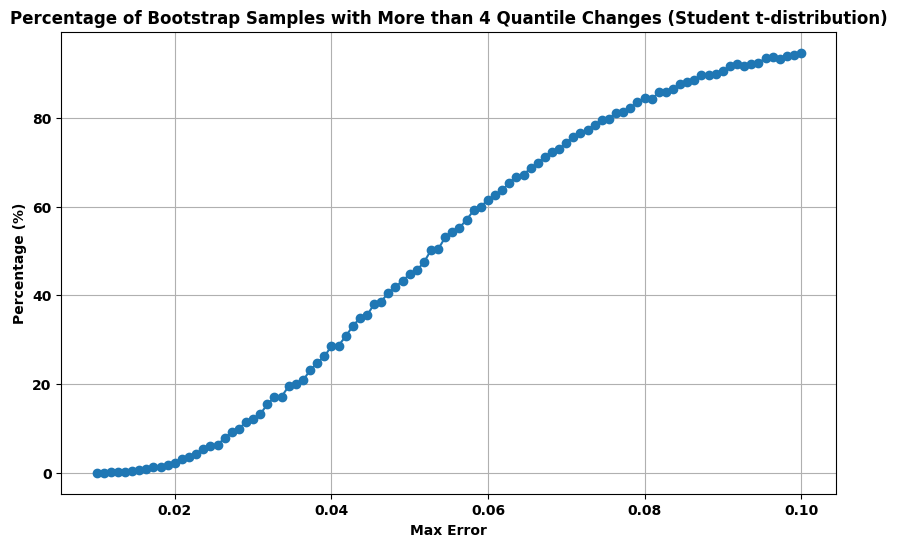

In [43]:
# Visualize the results
plt.figure(figsize=(10, 6))
plt.plot(max_errors, percent_wrong_student, marker='o')
plt.title('Percentage of Bootstrap Samples with More than 4 Quantile Changes (Student t-distribution)')
plt.xlabel('Max Error')
plt.ylabel('Percentage (%)')
plt.grid()
plt.show()

In [44]:
# # Same plot but with smoothing
# from scipy.interpolate import make_interp_spline
# import matplotlib.pyplot as plt

# # Create a smooth line using B-spline interpolation
# xnew = np.linspace(max_errors.min(), max_errors.max(), 300)
# spl = make_interp_spline(max_errors, percent_wrong_student, k=3)  # k=3 for cubic spline
# y_smooth = spl(xnew)

# # Plot the smoothed line
# plt.figure(figsize=(10, 6)) 
# plt.plot(xnew, y_smooth, color='blue')
# plt.plot(max_errors, percent_wrong_student, marker='o')
# plt.title('Percentage of Bootstrap Samples with More than 4 Quantile Changes (Smoothed)')
# plt.xlabel('Max Error') 
# plt.ylabel('Percentage (%)')
# plt.grid()
# plt.show()

In [45]:
print(max_errors.shape)
print(np.diff(max_errors))  # should all be > 0
print(np.unique(max_errors).size, len(max_errors))  # check for duplicates

(100,)
[-0.00090909 -0.00090909 -0.00090909 -0.00090909 -0.00090909 -0.00090909
 -0.00090909 -0.00090909 -0.00090909 -0.00090909 -0.00090909 -0.00090909
 -0.00090909 -0.00090909 -0.00090909 -0.00090909 -0.00090909 -0.00090909
 -0.00090909 -0.00090909 -0.00090909 -0.00090909 -0.00090909 -0.00090909
 -0.00090909 -0.00090909 -0.00090909 -0.00090909 -0.00090909 -0.00090909
 -0.00090909 -0.00090909 -0.00090909 -0.00090909 -0.00090909 -0.00090909
 -0.00090909 -0.00090909 -0.00090909 -0.00090909 -0.00090909 -0.00090909
 -0.00090909 -0.00090909 -0.00090909 -0.00090909 -0.00090909 -0.00090909
 -0.00090909 -0.00090909 -0.00090909 -0.00090909 -0.00090909 -0.00090909
 -0.00090909 -0.00090909 -0.00090909 -0.00090909 -0.00090909 -0.00090909
 -0.00090909 -0.00090909 -0.00090909 -0.00090909 -0.00090909 -0.00090909
 -0.00090909 -0.00090909 -0.00090909 -0.00090909 -0.00090909 -0.00090909
 -0.00090909 -0.00090909 -0.00090909 -0.00090909 -0.00090909 -0.00090909
 -0.00090909 -0.00090909 -0.00090909 -0.0009

In [46]:
# Define range of max errors and number of bootstraps
N_bootstrap = 10_000
max_errors = np.linspace(0.01, 0.035, 100)

# Set seed for repeatability
np.random.seed(42)

# Initialize arrays to store bootstrap results
bootstrap_quartile_changes_student = np.zeros((N_bootstrap, len(max_errors)))

for i_max_error in tqdm(range(len(max_errors))):
    max_error = max_errors[i_max_error]
    for i_bootstrap in range(N_bootstrap):

        # Get the ratings
        bootstrap_ratings = original_ratings.copy()

        for i_player in range(n_players):
            # Sample the errors
            samples = np.random.standard_t(size = number_of_actions[i_player], df=1) * max_error / cut_off_factor
            samples[samples > max_error] = max_error
            samples[samples < -max_error] = -max_error

            # Calculate the new rating
            # Rescale the samples to per 90 minutes
            bootstrap_ratings[i_player] += samples.sum()/number_of_minutes[i_player] * 90
        
        # Calculate the new quartiles
        # Note: pd.qcut returns 0-based indices, so we add 1 to make it 1-based
        bootstrap_quartiles = pd.qcut(bootstrap_ratings, 4, labels=False) + 1
        bootstrap_quartile_changes_student[i_bootstrap, i_max_error] = np.sum(bootstrap_quartiles != original_quartiles)

# Calculate the percentage of bootstrap samples with more than 4 quantile changes
N_wrong_student = (bootstrap_quartile_changes_student > 4).sum(axis=0)
percent_wrong_student = N_wrong_student / N_bootstrap * 100


100%|██████████| 100/100 [20:53<00:00, 12.53s/it]


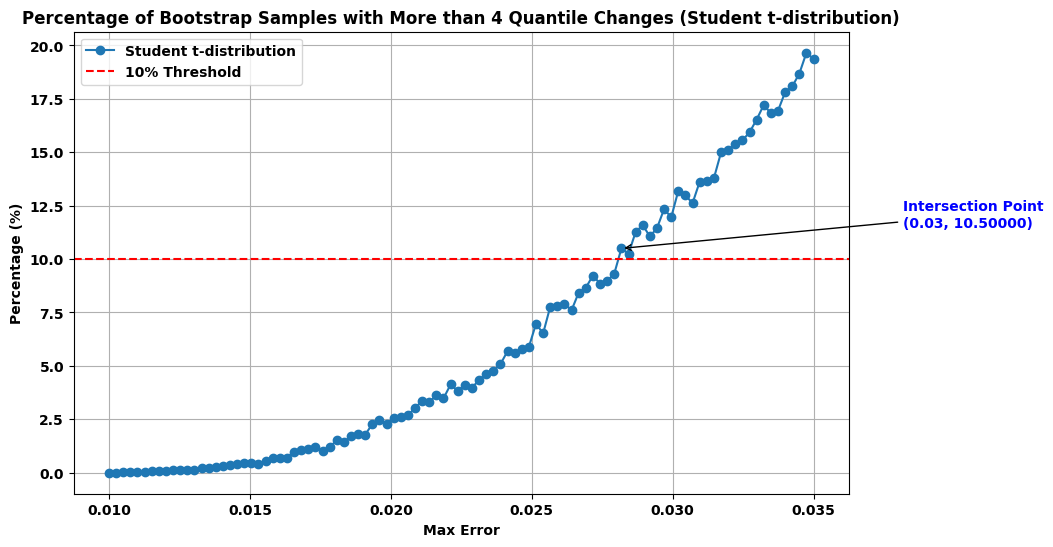

In [47]:
# Visualize the results
plt.figure(figsize=(10, 6))
plt.plot(max_errors, percent_wrong_student, marker='o', label='Student t-distribution')

# Add a line to indicate 5%
plt.axhline(y=10, color='r', linestyle='--', label='10% Threshold')

# Annotate the intersection point
intersection_idx = np.argwhere(percent_wrong_student - 10 > 0)[0][0]
intersection_x = max_errors[intersection_idx]
intersection_y = percent_wrong_student[intersection_idx]
plt.annotate(f'Intersection Point\n({intersection_x:.2f}, {intersection_y:.5f})',
             xy=(intersection_x, intersection_y), xytext=(intersection_x + 0.01, intersection_y + 1),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10, color='blue')

plt.title('Percentage of Bootstrap Samples with More than 4 Quantile Changes (Student t-distribution)')
plt.xlabel('Max Error')
plt.ylabel('Percentage (%)')
plt.legend()
plt.grid()
plt.show()

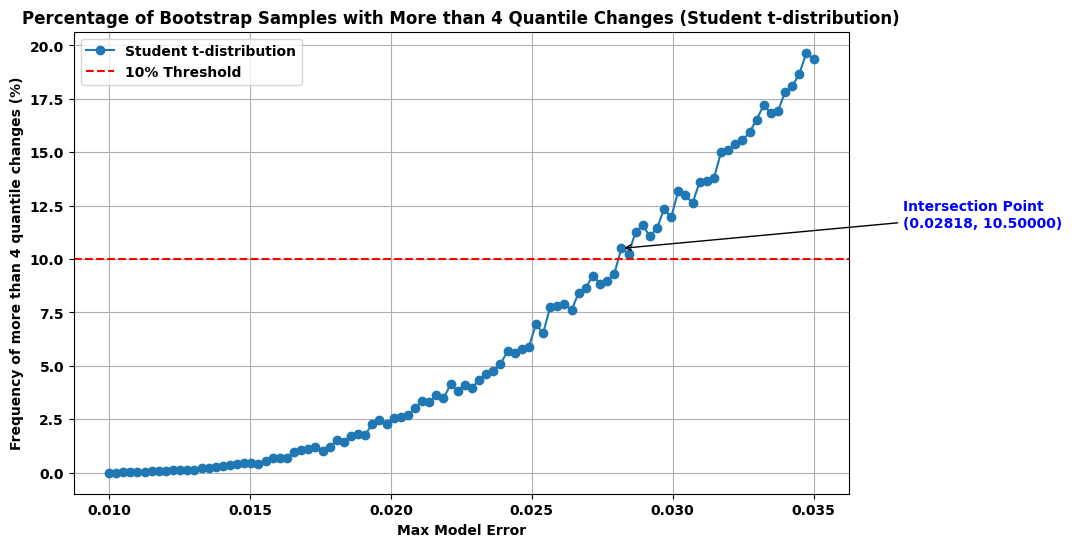

In [48]:
# Visualize the results
plt.figure(figsize=(10, 6))
plt.plot(max_errors, percent_wrong_student, marker='o', label='Student t-distribution')

# Add a line to indicate 5%
plt.axhline(y=10, color='r', linestyle='--', label='10% Threshold')

# Annotate the intersection point
intersection_idx = np.argwhere(percent_wrong_student - 10 > 0)[0][0]
intersection_x = max_errors[intersection_idx]
intersection_y = percent_wrong_student[intersection_idx]
plt.annotate(f'Intersection Point\n({intersection_x:.5f}, {intersection_y:.5f})',
             xy=(intersection_x, intersection_y), xytext=(intersection_x + 0.01, intersection_y + 1),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10, color='blue')

plt.title('Percentage of Bootstrap Samples with More than 4 Quantile Changes (Student t-distribution)')
plt.xlabel('Max Model Error')
plt.ylabel('Frequency of more than 4 quantile changes (%)')
plt.legend()
plt.grid()
plt.show()

In [49]:
# Define range of max errors and number of bootstraps
N_bootstrap = 100_000
max_errors = np.linspace(0.025, 0.035, 25)

# Set seed for repeatability
np.random.seed(42)

# Initialize arrays to store bootstrap results
bootstrap_quartile_changes_student = np.zeros((N_bootstrap, len(max_errors)))

for i_max_error in tqdm(range(len(max_errors))):
    max_error = max_errors[i_max_error]
    for i_bootstrap in range(N_bootstrap):

        # Get the ratings
        bootstrap_ratings = original_ratings.copy()

        for i_player in range(n_players):
            # Sample the errors
            samples = np.random.standard_t(size = number_of_actions[i_player], df=1) * max_error / cut_off_factor
            samples[samples > max_error] = max_error
            samples[samples < -max_error] = -max_error

            # Calculate the new rating
            # Rescale the samples to per 90 minutes
            bootstrap_ratings[i_player] += samples.sum()/number_of_minutes[i_player] * 90
        
        # Calculate the new quartiles
        # Note: pd.qcut returns 0-based indices, so we add 1 to make it 1-based
        bootstrap_quartiles = pd.qcut(bootstrap_ratings, 4, labels=False) + 1
        bootstrap_quartile_changes_student[i_bootstrap, i_max_error] = np.sum(bootstrap_quartiles != original_quartiles)

# Calculate the percentage of bootstrap samples with more than 4 quantile changes
N_wrong_student = (bootstrap_quartile_changes_student > 4).sum(axis=0)
percent_wrong_student = N_wrong_student / N_bootstrap * 100


100%|██████████| 25/25 [52:42<00:00, 126.50s/it]


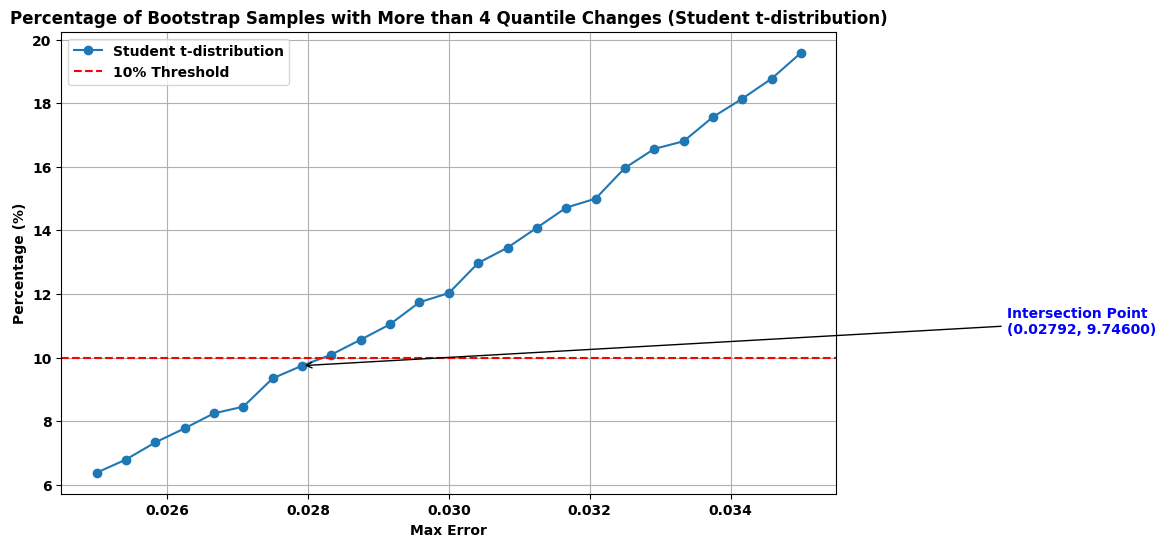

In [50]:
# Visualize the results
plt.figure(figsize=(10, 6))
plt.plot(max_errors, percent_wrong_student, marker='o', label='Student t-distribution')

# Add a line to indicate 5%
plt.axhline(y=10, color='r', linestyle='--', label='10% Threshold')

# Annotate the intersection point
intersection_idx = np.argwhere(percent_wrong_student < 10).max()
intersection_x = max_errors[intersection_idx]
intersection_y = percent_wrong_student[intersection_idx]
plt.annotate(f'Intersection Point\n({intersection_x:.5f}, {intersection_y:.5f})',
             xy=(intersection_x, intersection_y), xytext=(intersection_x + 0.01, intersection_y + 1),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10, color='blue')

plt.title('Percentage of Bootstrap Samples with More than 4 Quantile Changes (Student t-distribution)')
plt.xlabel('Max Error')
plt.ylabel('Percentage (%)')
plt.legend()
plt.grid()
plt.show()

# Perform simulations on full in-game set of players

In [51]:
all_xT_ratings = df_positive.groupby('player_id').agg(
    xT_sum=('action_xT', 'sum'),
    action_count=('action_xT', 'count'),
    Minutes=('Minutes', 'first'),
    main_position=('main_position', 'first'),
).reset_index()
all_xT_ratings['xT_per_90'] = all_xT_ratings['xT_sum'] / all_xT_ratings['Minutes'] * 90
all_xT_ratings['Quartile'] = pd.qcut(all_xT_ratings['xT_per_90'], 4, labels=False) + 1
all_xT_ratings

,player_id,xT_sum,action_count,Minutes,main_position,xT_per_90,Quartile
0,2954.0,0.725121,124,349,midfielder,0.186994,3
1,2988.0,1.403322,102,332,attacker,0.380419,4
2,2999.0,0.522738,275,415,defender,0.113365,2
3,3009.0,0.765843,81,415,attacker,0.166086,3
4,3026.0,0.445377,144,321,defender,0.124872,3
...,...,...,...,...,...,...,...
141,30328.0,0.393711,148,439,defender,0.080715,2
142,30486.0,1.815029,338,649,midfielder,0.251699,4
143,31900.0,1.337854,181,496,defender,0.242756,4
144,33018.0,0.921704,161,377,defender,0.220035,4


In [52]:
field_player_xT_ratings = all_xT_ratings[all_xT_ratings['main_position'] != 'Goalkeeper'].copy()
field_player_xT_ratings

,player_id,xT_sum,action_count,Minutes,main_position,xT_per_90,Quartile
0,2954.0,0.725121,124,349,midfielder,0.186994,3
1,2988.0,1.403322,102,332,attacker,0.380419,4
2,2999.0,0.522738,275,415,defender,0.113365,2
3,3009.0,0.765843,81,415,attacker,0.166086,3
4,3026.0,0.445377,144,321,defender,0.124872,3
...,...,...,...,...,...,...,...
141,30328.0,0.393711,148,439,defender,0.080715,2
142,30486.0,1.815029,338,649,midfielder,0.251699,4
143,31900.0,1.337854,181,496,defender,0.242756,4
144,33018.0,0.921704,161,377,defender,0.220035,4


In [53]:
# Prepare data for bootstrapping
field_player_xT_ratings.sort_values('player_id', inplace=True)
original_quartiles = field_player_xT_ratings['Quartile'].values
original_ratings = field_player_xT_ratings['xT_per_90'].values
number_of_actions = field_player_xT_ratings['action_count'].values
number_of_minutes = field_player_xT_ratings['Minutes'].values
n_players = len(original_ratings)

In [54]:
# Define range of max errors and number of bootstraps
N_bootstrap = 10_000
max_errors = np.linspace(0.1, 0.01, 50)

# Set seed for repeatability
np.random.seed(42)

# Initialize arrays to store bootstrap results
bootstrap_quartile_changes_student = np.zeros((N_bootstrap, len(max_errors)))

for i_max_error in tqdm(range(len(max_errors))):
    max_error = max_errors[i_max_error]
    for i_bootstrap in range(N_bootstrap):

        # Get the ratings
        bootstrap_ratings = original_ratings.copy()

        for i_player in range(n_players):
            # Sample the errors
            samples = np.random.standard_t(size = number_of_actions[i_player], df=1) * max_error / cut_off_factor
            samples[samples > max_error] = max_error
            samples[samples < -max_error] = -max_error

            # Calculate the new rating
            # Rescale the samples to per 90 minutes
            bootstrap_ratings[i_player] += samples.sum()/number_of_minutes[i_player] * 90
        
        # Calculate the new quartiles
        # Note: pd.qcut returns 0-based indices, so we add 1 to make it 1-based
        bootstrap_quartiles = pd.qcut(bootstrap_ratings, 4, labels=False) + 1
        bootstrap_quartile_changes_student[i_bootstrap, i_max_error] = np.sum(bootstrap_quartiles != original_quartiles)

# Calculate the percentage of bootstrap samples with more than 4 quantile changes
N_wrong_student = (bootstrap_quartile_changes_student > 14).sum(axis=0)
percent_wrong_student = N_wrong_student / N_bootstrap * 100


100%|██████████| 50/50 [26:40<00:00, 32.00s/it]


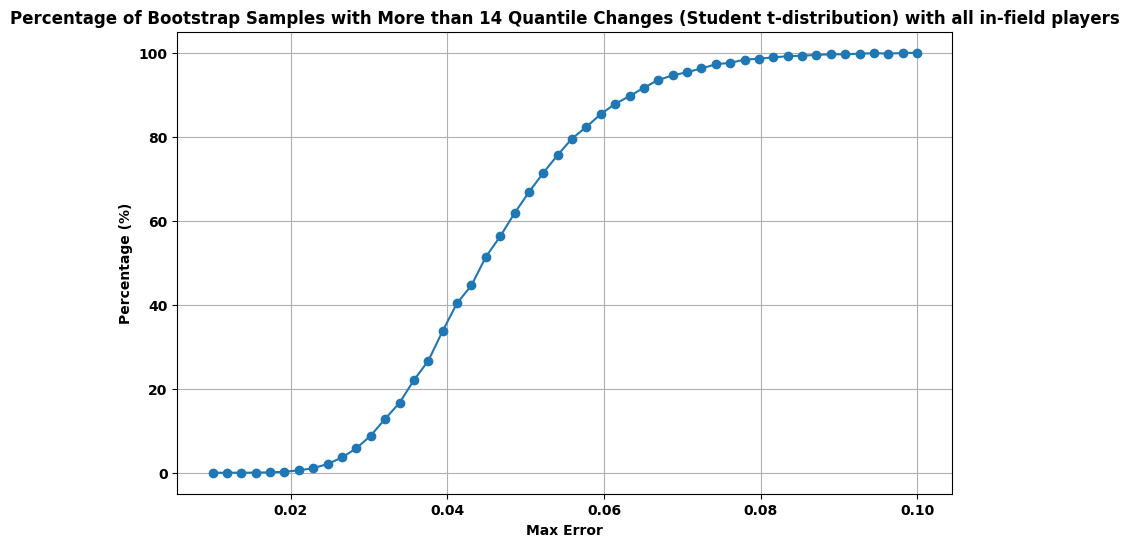

In [55]:
# Visualize the results
plt.figure(figsize=(10, 6))
plt.plot(max_errors, percent_wrong_student, marker='o')
plt.title('Percentage of Bootstrap Samples with More than 14 Quantile Changes (Student t-distribution) with all in-field players')
plt.xlabel('Max Error')
plt.ylabel('Percentage (%)')
plt.grid()
plt.show()

In [56]:
# Define range of max errors and number of bootstraps
N_bootstrap = 100_000
max_errors = np.linspace(0.02, 0.035, 50)

# Set seed for repeatability
np.random.seed(42)

# Initialize arrays to store bootstrap results
bootstrap_quartile_changes_student = np.zeros((N_bootstrap, len(max_errors)))

for i_max_error in tqdm(range(len(max_errors))):
    max_error = max_errors[i_max_error]
    for i_bootstrap in range(N_bootstrap):

        # Get the ratings
        bootstrap_ratings = original_ratings.copy()

        for i_player in range(n_players):
            # Sample the errors
            samples = np.random.standard_t(size = number_of_actions[i_player], df=1) * max_error / cut_off_factor
            samples[samples > max_error] = max_error
            samples[samples < -max_error] = -max_error

            # Calculate the new rating
            # Rescale the samples to per 90 minutes
            bootstrap_ratings[i_player] += samples.sum()/number_of_minutes[i_player] * 90
        
        # Calculate the new quartiles
        # Note: pd.qcut returns 0-based indices, so we add 1 to make it 1-based
        bootstrap_quartiles = pd.qcut(bootstrap_ratings, 4, labels=False) + 1
        bootstrap_quartile_changes_student[i_bootstrap, i_max_error] = np.sum(bootstrap_quartiles != original_quartiles)

# Calculate the percentage of bootstrap samples with more than 4 quantile changes
N_wrong_student = (bootstrap_quartile_changes_student > 14).sum(axis=0)
percent_wrong_student = N_wrong_student / N_bootstrap * 100


100%|██████████| 50/50 [6:45:06<00:00, 486.12s/it]   


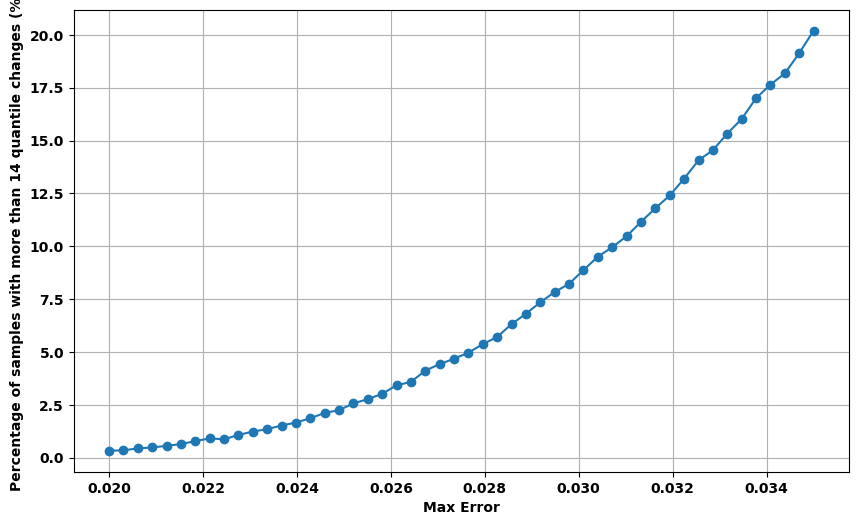

In [57]:
# Visualize the results
plt.figure(figsize=(10, 6))
plt.plot(max_errors, percent_wrong_student, marker='o')
# plt.title('Percentage of Bootstrap Samples with More than 14 Quantile Changes (Student t-distribution) with all in-field players')
plt.xlabel('Max Error')
plt.ylabel('Percentage of samples with more than 14 quantile changes (%)')
plt.grid()
plt.show()

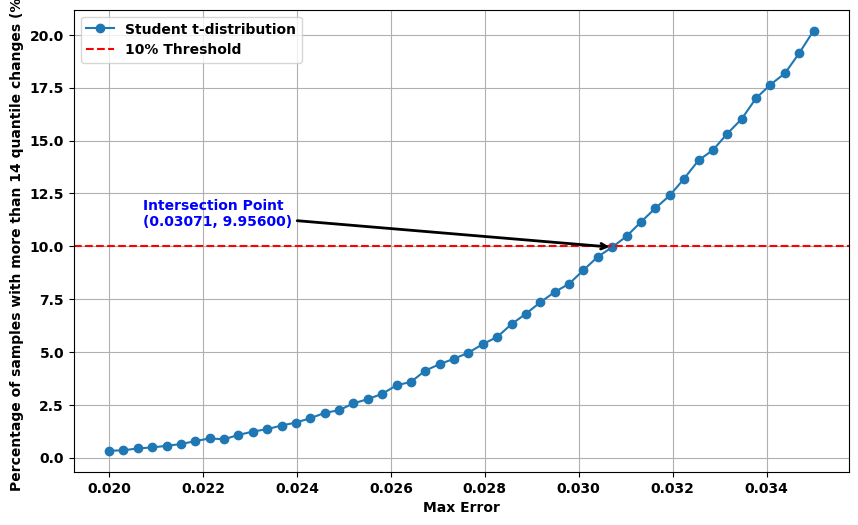

In [58]:
# Visualize the results
plt.figure(figsize=(10, 6))
plt.plot(max_errors, percent_wrong_student, marker='o', label='Student t-distribution')

# Add a line to indicate 5%
plt.axhline(y=10, color='r', linestyle='--', label='10% Threshold')

# Annotate the intersection point
intersection_idx = np.argwhere(percent_wrong_student < 10).max()
intersection_x = max_errors[intersection_idx]
intersection_y = percent_wrong_student[intersection_idx]
plt.annotate(f'Intersection Point\n({intersection_x:.5f}, {intersection_y:.5f})',
             xy=(intersection_x, intersection_y), xytext=(intersection_x - 0.01, intersection_y + 1),
             arrowprops=dict(facecolor='black', arrowstyle='->', lw=2.0),
             fontsize=10, color='blue')

# plt.title('Percentage of Bootstrap Samples with More than 14 Quantile Changes (Student t-distribution)')
plt.xlabel('Max Error')
plt.ylabel('Percentage of samples with more than 14 quantile changes (%)')
plt.legend()
plt.grid()
plt.show()

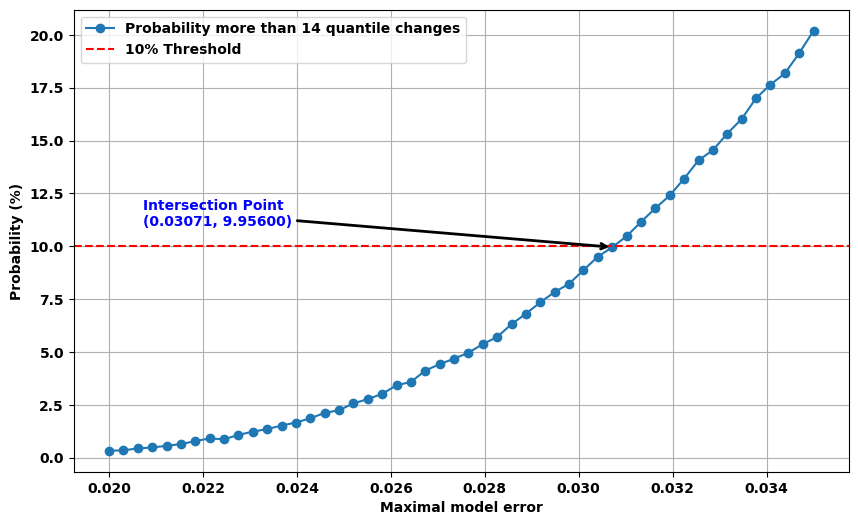

In [63]:
# Visualize the results
plt.figure(figsize=(10, 6))
plt.plot(max_errors, percent_wrong_student, marker='o', label='Probability more than 14 quantile changes')

# Add a line to indicate 5%
plt.axhline(y=10, color='r', linestyle='--', label='10% Threshold')

# Annotate the intersection point
intersection_idx = np.argwhere(percent_wrong_student < 10).max()
intersection_x = max_errors[intersection_idx]
intersection_y = percent_wrong_student[intersection_idx]
plt.annotate(f'Intersection Point\n({intersection_x:.5f}, {intersection_y:.5f})',
             xy=(intersection_x, intersection_y), xytext=(intersection_x - 0.01, intersection_y + 1),
             arrowprops=dict(facecolor='black', arrowstyle='->', lw=2.0),
             fontsize=10, color='blue')

# plt.title('Percentage of Bootstrap Samples with More than 14 Quantile Changes (Student t-distribution)')
plt.xlabel('Maximal model error')
plt.ylabel('Probability (%)')
plt.legend()
plt.grid()
plt.show()

In [61]:
print(intersection_x, intersection_y)

0.030714285714285715 9.956


In [59]:
# After this nothing was run

In [ ]:
# Visualize the results
plt.figure(figsize=(10, 6))
plt.plot(max_errors, percent_wrong_student, marker='o', label='Student t-distribution')

# Add a line to indicate 5%
plt.axhline(y=10, color='r', linestyle='--', label='10% Threshold')

# Annotate the intersection point
intersection_idx = np.argwhere(percent_wrong_student < 10).max()
intersection_x = max_errors[intersection_idx]
intersection_y = percent_wrong_student[intersection_idx]
plt.annotate(f'Intersection Point\n({intersection_x:.5f}, {intersection_y:.5f})',
             xy=(intersection_x, intersection_y), xytext=(intersection_x - 0.01, intersection_y + 1),
             arrowprops=dict(facecolor='black', arrowstyle='->', lw=2.0),
             fontsize=10, color='blue')

# plt.title('Percentage of Bootstrap Samples with More than 14 Quantile Changes (Student t-distribution)')
plt.xlabel('Max Error')
plt.ylabel('Percentage of samples with more than 14 quantile changes (%)')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Define range of max errors and number of bootstraps
N_bootstrap = 100_000
max_errors = np.linspace(0.02, 0.035, 50)

# Set seed for repeatability
np.random.seed(42)

# Initialize arrays to store bootstrap results
bootstrap_quartile_changes_student = np.zeros((N_bootstrap, len(max_errors)))

for i_max_error in tqdm(range(len(max_errors))):
    max_error = max_errors[i_max_error]
    for i_bootstrap in range(N_bootstrap):

        # Get the ratings
        bootstrap_ratings = original_ratings.copy()

        for i_player in range(n_players):
            # Sample the errors
            samples = np.random.standard_t(size = number_of_actions[i_player], df=1) * max_error / cut_off_factor
            samples[samples > max_error] = max_error
            samples[samples < -max_error] = -max_error

            # Calculate the new rating
            # Rescale the samples to per 90 minutes
            bootstrap_ratings[i_player] += samples.sum()/number_of_minutes[i_player] * 90
        
        # Calculate the new quartiles
        # Note: pd.qcut returns 0-based indices, so we add 1 to make it 1-based
        bootstrap_quartiles = pd.qcut(bootstrap_ratings, 4, labels=False) + 1
        bootstrap_quartile_changes_student[i_bootstrap, i_max_error] = np.sum(bootstrap_quartiles != original_quartiles)

# Calculate the percentage of bootstrap samples with more than 4 quantile changes
N_wrong_student = (bootstrap_quartile_changes_student > 14).sum(axis=0)
percent_wrong_student = N_wrong_student / N_bootstrap * 100


100%|██████████| 50/50 [31:01<00:00, 37.23s/it]


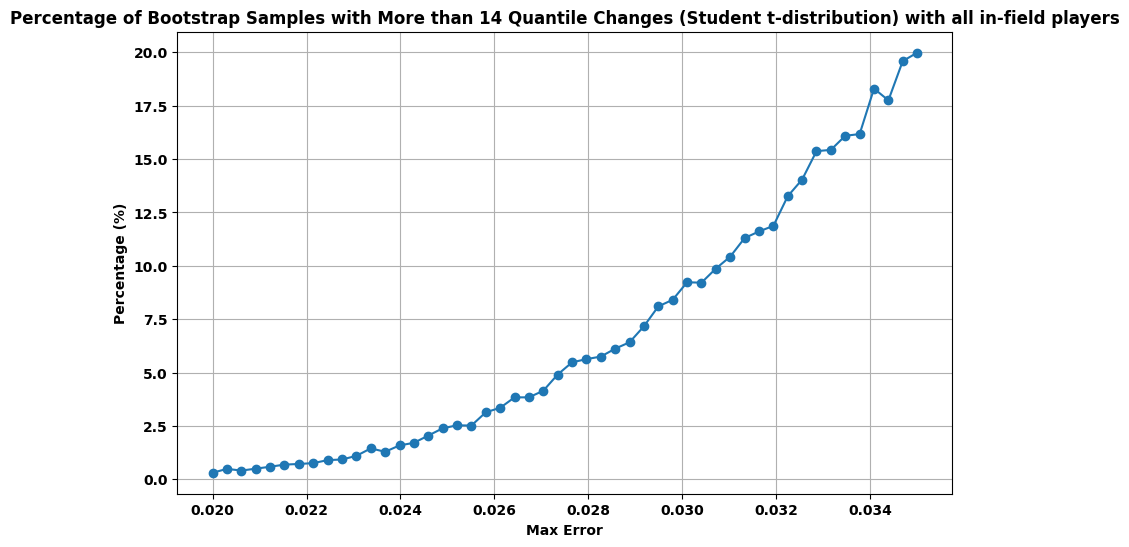

In [ ]:
# Visualize the results
plt.figure(figsize=(10, 6))
plt.plot(max_errors, percent_wrong_student, marker='o')
plt.title('Percentage of Bootstrap Samples with More than 14 Quantile Changes (Student t-distribution) with all in-field players')
plt.xlabel('Max Error')
plt.ylabel('Percentage (%)')
plt.grid()
plt.show()

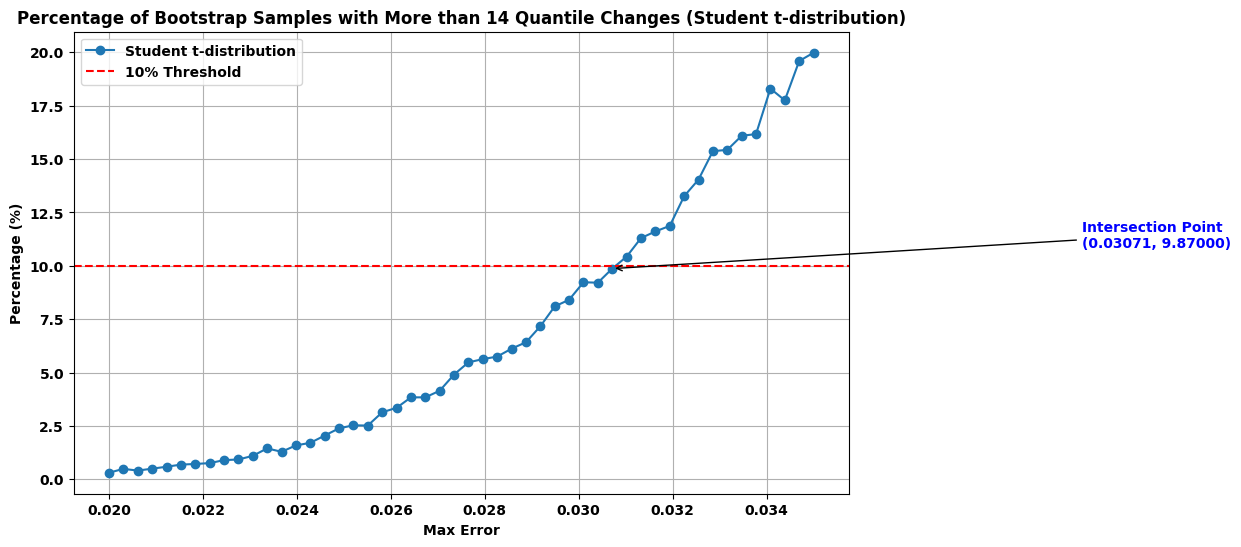

In [ ]:
# Visualize the results
plt.figure(figsize=(10, 6))
plt.plot(max_errors, percent_wrong_student, marker='o', label='Student t-distribution')

# Add a line to indicate 5%
plt.axhline(y=10, color='r', linestyle='--', label='10% Threshold')

# Annotate the intersection point
intersection_idx = np.argwhere(percent_wrong_student < 10).max()
intersection_x = max_errors[intersection_idx]
intersection_y = percent_wrong_student[intersection_idx]
plt.annotate(f'Intersection Point\n({intersection_x:.5f}, {intersection_y:.5f})',
             xy=(intersection_x, intersection_y), xytext=(intersection_x + 0.01, intersection_y + 1),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10, color='blue')

plt.title('Percentage of Bootstrap Samples with More than 14 Quantile Changes (Student t-distribution)')
plt.xlabel('Max Error')
plt.ylabel('Percentage (%)')
plt.legend()
plt.grid()
plt.show()

# Old

In [94]:
thetas = np.linspace(0.1, 0.01, 100)

# Initialize arrays to store bootstrap results
bootstrap_quartile_changes_student = np.zeros((N_bootstrap, len(thetas)))

for i_theta in tqdm(range(len(thetas))):
    theta = thetas[i_theta]
    for i_bootstrap in range(N_bootstrap):
        bootstrap_ratings = original_ratings.copy()

        for i_player in range(n_players):
            max_val = theta
            samples = np.random.standard_t(size = number_of_actions[i_player], df=1) * max_val / 100
            samples[samples > max_val] = max_val
            samples[samples < -max_val] = -max_val
            bootstrap_ratings[i_player] += samples.sum()/number_of_minutes[i_player] * 90
        bootstrap_quartiles = pd.qcut(bootstrap_ratings, 4, labels=False) + 1
        bootstrap_quartile_changes_student[i_bootstrap, i_theta] = np.sum(bootstrap_quartiles != original_quartiles)

# Calculate the percentage of bootstrap samples with more than 4 quantile changes
N_wrong_student = (bootstrap_quartile_changes_student > 4).sum(axis=0)
percent_wrong_student = N_wrong_student / N_bootstrap * 100


100%|██████████| 100/100 [20:24<00:00, 12.25s/it]


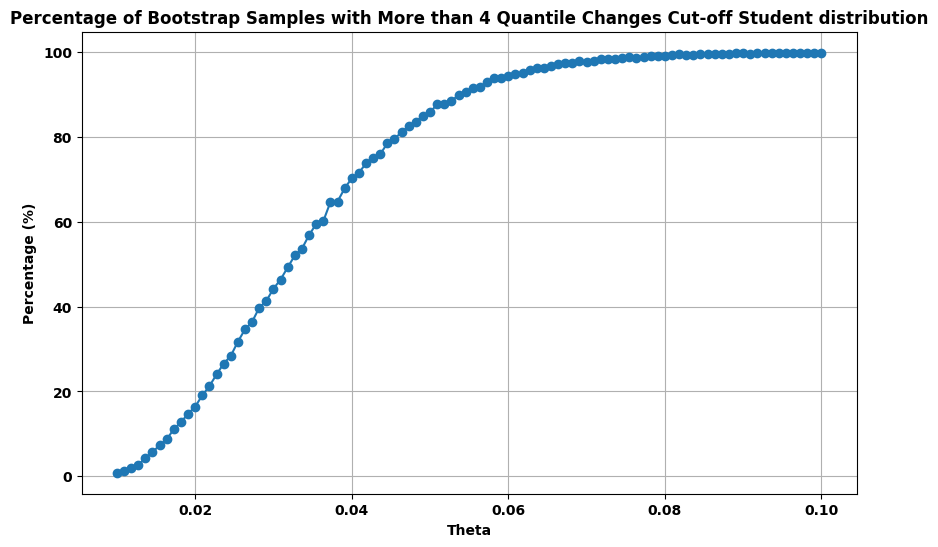

In [95]:
# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(thetas, percent_wrong_student, marker='o')
plt.title('Percentage of Bootstrap Samples with More than 4 Quantile Changes Cut-off Student distribution')
plt.xlabel('Theta')
plt.ylabel('Percentage (%)')


plt.grid()

plt.show()

In [97]:
thetas = np.linspace(0.01, 0.02)

# Initialize arrays to store bootstrap results
bootstrap_quartile_changes_student = np.zeros((N_bootstrap, len(thetas)))

for i_theta in tqdm(range(len(thetas))):
    theta = thetas[i_theta]
    for i_bootstrap in range(N_bootstrap):
        bootstrap_ratings = original_ratings.copy()

        for i_player in range(n_players):
            max_val = theta
            samples = np.random.standard_t(size = number_of_actions[i_player], df=1) * max_val / 100
            samples[samples > max_val] = max_val
            samples[samples < -max_val] = -max_val
            bootstrap_ratings[i_player] += samples.sum()/number_of_minutes[i_player] * 90
        bootstrap_quartiles = pd.qcut(bootstrap_ratings, 4, labels=False) + 1
        bootstrap_quartile_changes_student[i_bootstrap, i_theta] = np.sum(bootstrap_quartiles != original_quartiles)

# Calculate the percentage of bootstrap samples with more than 4 quantile changes
N_wrong_student = (bootstrap_quartile_changes_student > 4).sum(axis=0)
percent_wrong_student = N_wrong_student / N_bootstrap * 100


100%|██████████| 50/50 [13:31<00:00, 16.23s/it]


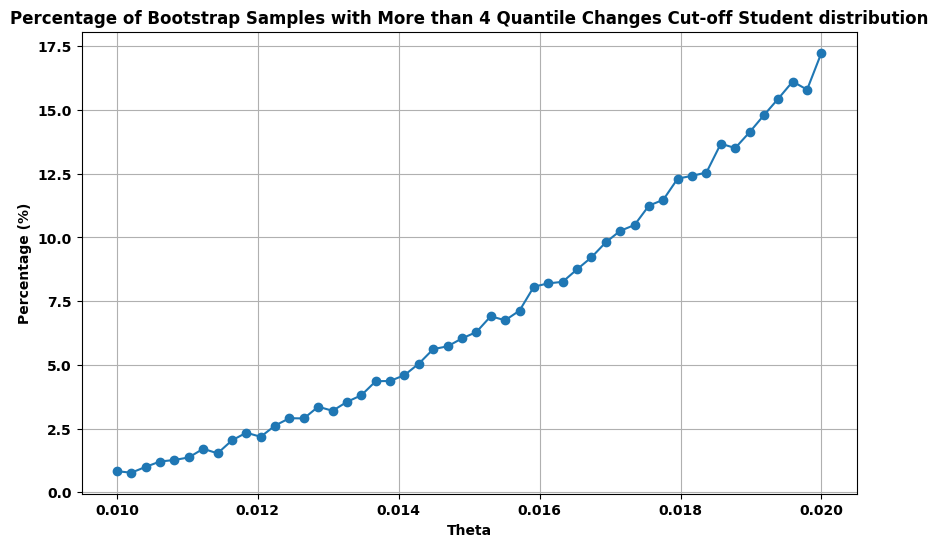

In [98]:
# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(thetas, percent_wrong_student, marker='o')
plt.title('Percentage of Bootstrap Samples with More than 4 Quantile Changes Cut-off Student distribution')
plt.xlabel('Theta')
plt.ylabel('Percentage (%)')


plt.grid()

plt.show()

In [23]:
thetas = np.linspace(0.01, 0.02)

N_bootstrap_detailed = 100_000

# Initialize arrays to store bootstrap results
bootstrap_quartile_changes_student = np.zeros((N_bootstrap_detailed, len(thetas)))

for i_theta in tqdm(range(len(thetas))):
    theta = thetas[i_theta]
    for i_bootstrap in range(N_bootstrap_detailed):
        bootstrap_ratings = original_ratings.copy()

        for i_player in range(n_players):
            max_val = theta
            samples = np.random.standard_t(size = number_of_actions[i_player], df=1) * max_val / 100
            samples[samples > max_val] = max_val
            samples[samples < -max_val] = -max_val
            bootstrap_ratings[i_player] += samples.sum()/number_of_minutes[i_player] * 90
        bootstrap_quartiles = pd.qcut(bootstrap_ratings, 4, labels=False) + 1
        bootstrap_quartile_changes_student[i_bootstrap, i_theta] = np.sum(bootstrap_quartiles != original_quartiles)

# Calculate the percentage of bootstrap samples with more than 4 quantile changes
N_wrong_student = (bootstrap_quartile_changes_student > 4).sum(axis=0)
percent_wrong_student = N_wrong_student / N_bootstrap_detailed * 100


100%|██████████| 50/50 [3:11:10<00:00, 229.41s/it]  


In [1]:
# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(thetas, percent_wrong_student, marker='o')
plt.title('Percentage of Bootstrap Samples with More than 4 Quantile Changes Cut-off Student distribution')
plt.xlabel('Theta')
plt.ylabel('Percentage (%)')


plt.grid()

plt.show()

NameError: name 'plt' is not defined

# Model error in player rating

In [25]:
print(f"Minutes average = {np.mean(number_of_minutes):.2f} and std = {np.std(number_of_minutes):.2f}")
print(f"Actions average = {np.mean(number_of_actions):.2f} and std = {np.std(number_of_actions):.2f}")
print(f"Actions average = {np.mean(number_of_actions)/np.mean(number_of_minutes):.2f} and std = {np.std(number_of_actions)/np.std(number_of_minutes):.2f}")

Minutes average = 417.34 and std = 101.29
Actions average = 162.98 and std = 84.63
Actions average = 0.39 and std = 0.84


In [26]:
90*np.sqrt(np.mean(number_of_actions)/np.mean(number_of_minutes))

np.float64(56.241649488286065)

In [27]:
0.05/56

0.0008928571428571429